# Wasserstein-Fisher-Rao Gradient Flow with Adaptive Biasing Force

## Setup

### Potential

$$
V(x, y) = 3 e^{-x^2} \left( e^{- \left(y - \frac{1}{3}\right)^2} - e^{- \left(y - \frac{5}{3} \right)^2} \right) - 5 e^{-y^2} \left( e^{-(x - 1)^2} + e^{- (x + 1)^2} \right) + 0.2x^4 + 0.2 \left(y - \frac{1}{3}\right)^4.
$$

### Boltzmann distribution

$$
\pi_\beta \propto \exp (-\beta V(x, y)).
$$

![Target density with $\beta = 4$](fig/target_density_beta4.png)

### Reaction coordinate and free energy

The reaction coordinate is on the $x$-axis:
$$
\xi(x, y) = x,
$$
and the free energy is hence defined as
$$
F(z) = -\frac{1}{\beta} \ln{\frac{Z(z)}{Z}}, \qquad Z(z) = \int \exp(-\beta V(x, y)) dy, \qquad Z = \int \int \exp (-\beta V(x, y)) dx dy.
$$

We then compute that $\nabla\xi = (1, 0)$ and $|\nabla\xi| = 1$, hence the local mean force is simply 
$$f (x, y) = \partial_x V(x, y),$$
and furthermore
$$
F'(z) = \mathbb{E}_\pi [\partial_x V(X, Y) \mid X = z] = \frac{\int \partial_x V(z, y) \exp(-\beta V(z, y)) dy}{\int \exp(-\beta V(z, y)) dy}.
$$

## Current Plan

We restrict the domain in $[-c, c]^2$ using the similar strategy as in `eABF.ipynb`, and let $\rho_t(x, y)$ be the time-dependent density on domain $[-c, c]^2$. The marginal distribution on $x$-coordinate is hence
$$
p_t (x) = \int_{-c}^c \rho_t (x, y) dy.
$$

### Langevin dynamics with ABF
Let $A_t$ be the ABF estimate of the free energy, with its derivative $A_t'(x)$ estimating $F'(x)$, then the Langevin dynamics with ABF reads
$$
\begin{cases}
d X_t = (-\partial_x V(X_t, Y_t) + A_t' (X_t)) dt + \sqrt{\frac{2}{\beta}} d W_t^x, \\
d Y_t = -\partial_y V(X_t, Y_t) dt + \sqrt{\frac{2}{\beta}} d W_t^y,
\end{cases}
$$
with the (ideal) ABF estimator given by
$$
A_t' (x) = \mathbb{E}_{\rho_t} [\partial_x V(X, Y) \mid X = x] = \frac{\int_{-c}^c \partial_x V(x, y) \rho_t (x, y) dy}{\int_{-c}^c \rho_t (x, y) dy},
$$
and the kernel estimation is 
$$
A_t' (x) = \frac{\int\int K_h (x - x') \partial_{x'} V(x', y') \rho_t (x', y') dx'dy'}{\int\int K_h (x - x') \rho_t (x', y') dx'dy'}.
$$

### Fisher-Rao (Birth/Death)
If the ABF is exact, i.e., $A(x) = F(x)$, then the biased density would be $\pi_A (x, y) \propto \exp (-\beta (V(x, y) - F(x)))$, whose marginal in $x$-coordinate is 
$$
\int_{-c}^c \exp (-\beta (V(x, y) - F(x))) dy = \exp (\beta F(x)) Z(x) = Z,
$$
so the marginal along $x$ is hence the (flattened) uniform distribution $u(x) = \frac{1}{2c} \mathbf{1}_{[-c, c]} (x)$, the birth-death term reads
$$
\mathcal{R}[\rho_t](x, y) = -\gamma \rho_t (x, y) \left( \ln{\frac{p_t(x)}{u(x)}} - \int_{-c}^c p_t(z) \ln{\frac{p_t(z)}{u(z)}} dz \right)
$$
with $\int\int \mathcal{R}[\rho_t](x, y)dxdy = 0$.

### PDE
$$
\partial_t \rho_t = \frac{1}{\beta} (\partial_{xx} \rho_t + \partial_{yy} \rho_t) + \partial_x ((\partial_x V - A_t'(x)) \rho_t) + \partial_y ((\partial_y V) \rho_t) - \gamma \rho_t (x, y) \left( \ln{\frac{p_t(x)}{u(x)}} - \int_{-c}^c p_t(z) \ln{\frac{p_t(z)}{u(z)}} dz \right),
$$
or the kernelized version
$$
\begin{align*}
\partial_t \rho_t &= \frac{1}{\beta} (\partial_{xx} \rho_t + \partial_{yy} \rho_t) + \partial_x ((\partial_x V - A_t'(x)) \rho_t) + \partial_y ((\partial_y V) \rho_t)\\
&\qquad - \gamma \rho_t (x, y) \left( \ln{\frac{(K_\eta * p_t)(x)}{u(x)}} + K_\eta * \left( \frac{p_t}{K_\eta * p_t} \right)(x) - \int_{-c}^c p_t(z) \ln{\frac{(K_\eta * p_t)(z)}{u(z)}} dz - 1 \right).
\end{align*}
$$

## Numerical implementation with $N$ particles

Setup: $N$ particles $(X_n^i, Y_n^i)$ at timestep $n$

### 1. Estimating ABF
$$
\hat A_n'(x) = \frac{\sum_{i=1}^N K_h (x - X_n^i) \partial_x V(X_n^i, Y_n^i)}{\sum_{i=1}^N K_h (x - X_n^i)}.
$$

### 2. Langevin dynamics with ABF
$$
\begin{cases}
\tilde X_{n+1}^i = X_n^i + (-\partial_x V(X_n^i, Y_n^i) + \hat A_t'(X_n^i)) \Delta t + \sqrt{2\Delta t/\beta} \xi_n^{i, x},\\
\tilde Y_{n+1}^i = Y_n^i - \partial_y V(X_n^i, Y_n^i) \Delta t + \sqrt{2\Delta t/\beta} \xi_n^{i, y}.
\end{cases}
$$

### 3. Estimate marginal on $x$-coordinate
$$
\hat p_{n+1}(x) = \frac{1}{N} \sum_{i=1}^N K_\eta (x - \tilde X_{n+1}^i).
$$

### 4. Birth-death on $x$-coordinate
For particle $i$, define its birth-death score
$$
\hat S_{n+1} (\tilde X_{n+1}^i) = \ln{\hat p_{n+1} (\tilde X_{n+1}^i)} - \frac{1}{N} \sum_{j=1}^N \ln{\hat p_{n+1} (X_{n+1}^j)}
$$
or the kernelized version
$$
\hat S_{n+1}^\eta (\tilde X_n^i) = \ln{\hat p_{n+1} (\tilde X_{n+1}^i)} + \frac{1}{N} \sum_{j=1}^N \frac{K_\eta (\tilde X_{n+1}^i - \tilde X_{n+1}^j)}{\hat p_{n+1} (X_{n+1}^j)} - \frac{1}{N} \sum_{j=1}^N \ln{\hat p_{n+1} (X_{n+1}^j)} - 1,
$$
then:
* if $\hat S_{n+1} (\tilde X_{n+1}^i) > 0$, kill particle $i$ with probability $1 - e^{-\gamma \hat S_{n+1} (\tilde X_{n+1}^i) \Delta t}$ and clone another particle with uniform probability;
* if $\hat S_{n+1} (\tilde X_{n+1}^i) < 0$, clone particle $i$ with probability $1 - e^{\gamma \hat S_{n+1} (\tilde X_{n+1}^i) \Delta t}$ and kill another particle with uniform probability.

After birth-death step, we denote the resulting particle system by
$$(X_{n+1}^i, Y_{n+1}^i), \qquad i = 1, \ldots, N.$$

## Hyperparameters

In [1]:
import numpy as np
import scipy.integrate as integrate
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

rng = np.random.default_rng(42)

# ── Domains ─────────────────────────────────────────────────────────────────
ZMIN, ZMAX = -3.0, 3.0    # reaction-coordinate (x) domain for biased dynamics
YMIN, YMAX = -3.0, 3.0    # y domain

# ── Physical parameters ─────────────────────────────────────────────────────
beta   = 4.0               # inverse temperature

# ── Particle / time parameters ───────────────────────────────────────────────
N          = 1000          # number of particles
dt         = 2e-3          # time-step
n_steps    = 5000          # total Euler–Maruyama steps
save_every = 200           # save diagnostics every this many steps

# ── Birth-death rate ----─────────────────────────────────────────────────────
gamma = 0.05               # conservative rate on the smaller x-domain [-3,3]

# ── Bandwidths ───────────────────────────────────────────────────────────────
h   = 0.05                 # ABF kernel bandwidth (on x)
eta = 0.10                 # KDE bandwidth for p_hat and kernelized Fisher-Rao score

# ── Reference / diagnostic grid on [-3,3] ────────────────────────────────────
n_grid = 200
z_grid = np.linspace(ZMIN, ZMAX, n_grid)
dz     = z_grid[1] - z_grid[0]

# ── Quadrature grid for y-integrals in reference computation ─────────────────
n_quad = 200
y_quad = np.linspace(YMIN, YMAX, n_quad)

# ── Flat biased target u(z) = 1/(ZMAX-ZMIN) on z_grid ───────────────────────
u_target = np.full(n_grid, 1.0 / (ZMAX - ZMIN))

# ── Numerical safety floor ───────────────────────────────────────────────────
EPS = 1e-30

## Setup

### Potential

$$
V(x, y) = 3 e^{-x^2} \left( e^{- \left(y - \frac{1}{3}\right)^2} - e^{- \left(y - \frac{5}{3} \right)^2} \right) - 5 e^{-y^2} \left( e^{-(x - 1)^2} + e^{- (x + 1)^2} \right) + 0.2x^4 + 0.2 \left(y - \frac{1}{3}\right)^4.
$$

### Gradients

$$
\frac{\partial V}{\partial x} = -6x e^{-x^2} \left( e^{- \left(y - \frac{1}{3}\right)^2} - e^{- \left(y - \frac{5}{3} \right)^2} \right) - 5 e^{-y^2} \left( -2(x - 1) e^{-(x - 1)^2} - 2 (x + 1) e^{-(x + 1)^2} \right) + 0.8x^3,
$$

$$
\frac{\partial V}{\partial y} = 3 e^{-x^2} \left( -2 \left(y - \frac{1}{3}\right) e^{- \left(y - \frac{1}{3}\right)^2} + 2 \left(y - \frac{5}{3} \right) e^{- \left(y - \frac{5}{3} \right)^2} \right) + 10 y e^{-y^2} \left( e^{-(x - 1)^2} + e^{- (x + 1)^2} \right) + 0.8 \left( y - \frac{1}{3} \right)^3.
$$

### Reflect functions
constrain `x` and `y` in certain domains


In [2]:
# ── Potential and gradients ────────────────────────────────────────────────

def V(x, y):
    t1 = 3.0 * np.exp(-x**2) * (np.exp(-(y - 1/3)**2) - np.exp(-(y - 5/3)**2))
    t2 = -5.0 * np.exp(-y**2) * (np.exp(-(x - 1)**2) + np.exp(-(x + 1)**2))
    t3 = 0.2 * x**4 + 0.2 * (y - 1/3)**4
    return t1 + t2 + t3


def dVdx(x, y):
    A    = np.exp(-(y - 1/3)**2) - np.exp(-(y - 5/3)**2)
    d_t1 = 3.0 * (-2.0 * x) * np.exp(-x**2) * A
    B    = np.exp(-y**2)
    d_t2 = -5.0 * B * ((-2.0*(x-1))*np.exp(-(x-1)**2) + (-2.0*(x+1))*np.exp(-(x+1)**2))
    d_t3 = 0.8 * x**3
    return d_t1 + d_t2 + d_t3


def dVdy(x, y):
    """Partial derivative ∂V/∂y."""
    d_t1 = 3.0 * np.exp(-x**2) * (
        (-2.0*(y - 1/3))*np.exp(-(y - 1/3)**2)
        - (-2.0*(y - 5/3))*np.exp(-(y - 5/3)**2))
    C    = np.exp(-(x - 1)**2) + np.exp(-(x + 1)**2)
    d_t2 = -5.0 * (-2.0*y) * np.exp(-y**2) * C
    d_t3 = 0.8 * (y - 1/3)**3
    return d_t1 + d_t2 + d_t3


# ── Separate reflection helpers for x and y ────────────────────────────────

def _reflect_1d(q, lo, hi):
    """Fold array q into [lo, hi] by specular reflection."""
    q    = q.copy()
    span = hi - lo
    q   -= lo
    q    = q % (2 * span)
    q[q > span] = 2 * span - q[q > span]
    q   += lo
    return q

def reflect_x(q):
    """Reflect x-coordinates into [ZMIN, ZMAX]."""
    return _reflect_1d(q, ZMIN, ZMAX)

def reflect_y(q):
    """Reflect y-coordinates into [YMIN, YMAX]."""
    return _reflect_1d(q, YMIN, YMAX)


### Visualization of potential and target distribution

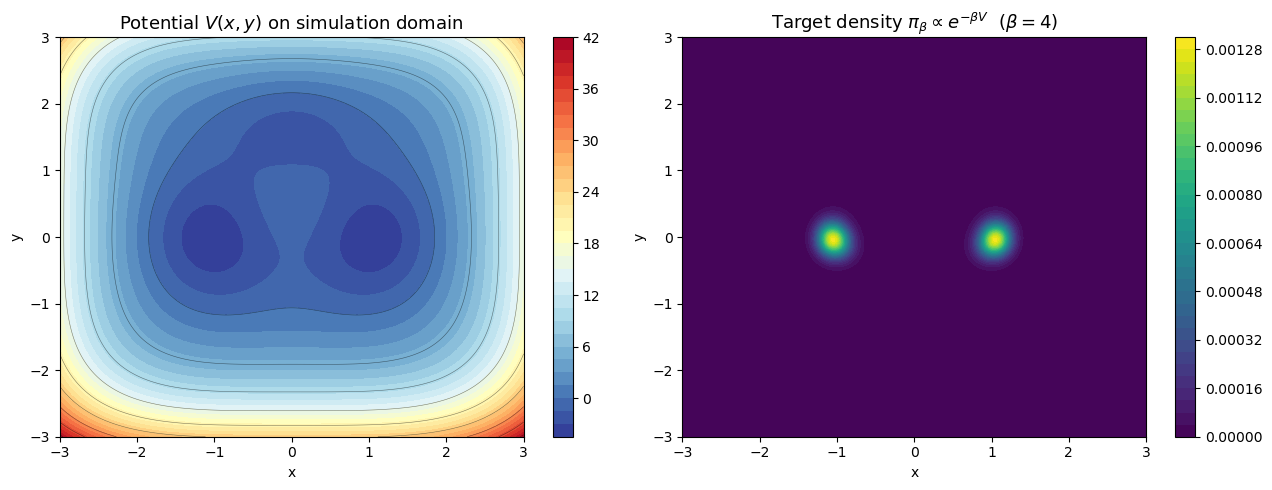

In [3]:
xg = np.linspace(ZMIN, ZMAX, 300)
yg = np.linspace(YMIN, YMAX, 300)
XX, YY = np.meshgrid(xg, yg)

VV      = V(XX, YY)
pi_beta = np.exp(-beta * VV)
pi_beta /= pi_beta.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

c0 = axes[0].contourf(XX, YY, VV, levels=40, cmap='RdYlBu_r')
axes[0].contour(XX, YY, VV, levels=10, colors='k', linewidths=0.4, alpha=0.5)
plt.colorbar(c0, ax=axes[0])
axes[0].set_title(r"Potential $V(x,y)$ on simulation domain", fontsize=13)
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

c1 = axes[1].contourf(XX, YY, pi_beta, levels=40, cmap='viridis')
plt.colorbar(c1, ax=axes[1])
axes[1].set_title(r"Target density $\pi_\beta \propto e^{-\beta V}$  ($\beta=%g$)" % beta,
                  fontsize=13)
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()

## Computing Adaptive Biasing Force


### Gaussian kernel

$$
K_h (x) = \frac{1}{h \sqrt{2\pi}} \exp \left( -\frac{1}{2} \left( \frac{x}{h} \right)^2\right),
\qquad
K_\eta (x) = \frac{1}{\eta \sqrt{2\pi}} \exp \left( -\frac{1}{2} \left( \frac{x}{\eta} \right)^2\right)
$$

### Marginal distribution

through KDE with Gaussian kernel

### Compute $\hat A$ and $\hat A'$

to approximate free energy $F$ and mean force $F'$ (or $f$)

In [4]:

# ── Gaussian kernels ────────────────────────────────────────────────────────

def gaussian_kernel(u, bw):
    return np.exp(-0.5 * (u / bw)**2) / (bw * np.sqrt(2.0 * np.pi))

def K_h(u):   return gaussian_kernel(u, h)
def K_eta(u): return gaussian_kernel(u, eta)

# ── KDE of x-marginal ─

def compute_p_hat(x_eval, X_tilde):
    x_eval  = np.atleast_1d(np.asarray(x_eval, dtype=float))
    N_part  = len(X_tilde)
    X_left  = 2.0 * ZMIN - X_tilde
    X_right = 2.0 * ZMAX - X_tilde
    X_all   = np.concatenate([X_left, X_tilde, X_right])
    diff    = x_eval[:, None] - X_all[None, :]
    p       = np.sum(K_eta(diff), axis=1) / N_part
    return np.maximum(p, EPS)


# ── Running-average ABF accumulators on z_grid ─────────────────────────────

def init_abf_accumulators(n_grid):
    """Return zero-filled (num_acc, den_acc) arrays."""
    return np.zeros(n_grid), np.zeros(n_grid)


def update_abf_accumulators(num_acc, den_acc, X, Y, z_grid):
    """Add the current particle batch to the running ABF accumulators (in-place).

    num_acc[m] += Σ_i K_h(z_m - X^i) * dVdx(X^i, Y^i)
    den_acc[m] += Σ_i K_h(z_m - X^i)
    """
    diff     = z_grid[:, None] - X[None, :]          # (n_grid, N)
    weights  = K_h(diff)                             # (n_grid, N)
    num_acc += np.sum(weights * dVdx(X, Y)[None, :], axis=1)
    den_acc += np.sum(weights, axis=1)


def compute_abf_prime_from_acc(num_acc, den_acc):
    """Â'(z) = num_acc / den_acc."""
    return num_acc / np.maximum(den_acc, EPS)


# ── ABF integration and interpolation helpers ───────────────────────────────

def integrate_abf_prime(Ahat_prime, z_grid):
    """Cumulative-trapezoid integral of Â', pinned to 0 at z nearest 0."""
    Ahat  = integrate.cumulative_trapezoid(Ahat_prime, z_grid, initial=0.0)
    idx0  = np.argmin(np.abs(z_grid))
    Ahat -= Ahat[idx0]
    return Ahat


def make_abf_interpolant(Ahat_prime, z_grid):
    """Linear interpolant of Â'(x); constant edge fill outside grid."""
    return interp1d(z_grid, Ahat_prime, kind='linear',
                    bounds_error=False,
                    fill_value=(Ahat_prime[0], Ahat_prime[-1]))

## True free energy and mean force

We compute the exact free energy and mean force by numerical integration over the `y`-direction for each `z` in `z_grid`:

$$Z(z) = \int e^{-\beta V(z,y)}\,dy, \qquad
F'(z) = \frac{\int \partial_x V(z,y)\,e^{-\beta V(z,y)}\,dy}{Z(z)}.$$

In [5]:
def compute_reference(z_grid, y_quad, beta):
    """
    Compute reference quantities for the ABF simulation.

    Returns
    -------
    log_Z
    F_ref
    Fprime_ref
    """
    n_z = len(z_grid)
    n_y = len(y_quad)
    dy  = y_quad[1] - y_quad[0]

    zz = z_grid[:, None] * np.ones((1, n_y))
    yy = np.ones((n_z, 1)) * y_quad[None, :]

    phi      = beta * V(zz, yy)
    dvdx_mat = dVdx(zz, yy)

    m      = phi.min(axis=1, keepdims=True)
    w      = np.exp(-(phi - m))

    Z_stab = np.sum(w, axis=1) * dy

    log_Z  = -m[:, 0] + np.log(Z_stab)

    Fprime_ref = np.sum(dvdx_mat * w, axis=1) * dy / Z_stab

    idx0  = np.argmin(np.abs(z_grid))
    F_ref = -(1.0 / beta) * (log_Z - log_Z[idx0])

    return log_Z, F_ref, Fprime_ref


log_Z, F_ref, Fprime_ref = compute_reference(z_grid, y_quad, beta)

_lz      = log_Z - log_Z.max()
_p_unnorm = np.exp(_lz)
p_ref_unbiased = _p_unnorm / np.trapezoid(_p_unnorm, z_grid)


### Visualization

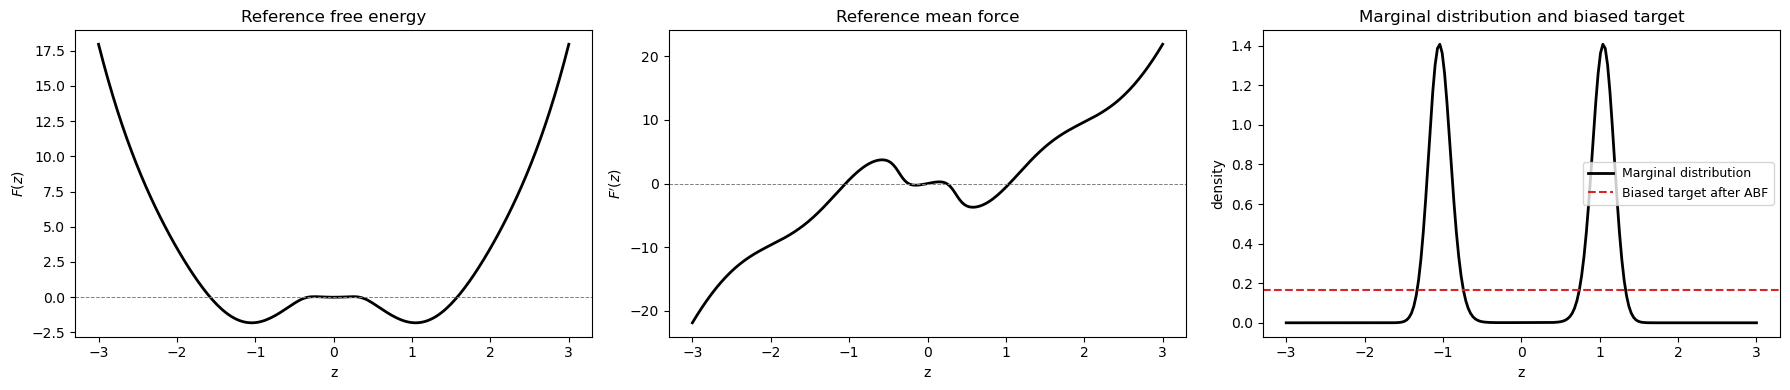

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(z_grid, F_ref, 'k-', lw=2)
axes[0].axhline(0, color='gray', lw=0.7, ls='--')
axes[0].set_xlabel("z"); axes[0].set_ylabel(r"$F(z)$")
axes[0].set_title(r"Reference free energy")

axes[1].plot(z_grid, Fprime_ref, 'k-', lw=2)
axes[1].axhline(0, color='gray', lw=0.7, ls='--')
axes[1].set_xlabel("z"); axes[1].set_ylabel(r"$F'(z)$")
axes[1].set_title(r"Reference mean force")

axes[2].plot(z_grid, p_ref_unbiased, 'k-', lw=2, label="Marginal distribution")
axes[2].axhline(1.0 / (ZMAX - ZMIN), color='C3', lw=1.5, ls='--',
                label="Biased target after ABF")
axes[2].set_xlabel("z"); axes[2].set_ylabel("density")
axes[2].set_title("Marginal distribution and biased target")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Birth-death dynamics

### Fisher-Rao score functions
incl. simple and kernelized versions

### Birth-death resampling

In [7]:
def score_simple(X_tilde, p_hat_at_particles, p_hat_on_grid, z_grid):
    log_p = np.log(np.maximum(p_hat_at_particles, EPS))
    grid_baseline = np.trapezoid(
        p_hat_on_grid * np.log(np.maximum(p_hat_on_grid, EPS)), z_grid
    )
    return log_p - grid_baseline


def score_kernelized(X_tilde, p_hat_at_particles, p_hat_on_grid, z_grid):
    log_p          = np.log(np.maximum(p_hat_at_particles, EPS))
    grid_baseline  = np.trapezoid(
        p_hat_on_grid * np.log(np.maximum(p_hat_on_grid, EPS)), z_grid
    )
    diff           = X_tilde[:, None] - X_tilde[None, :]          # (N, N)
    K_mat          = K_eta(diff)
    kernel_term    = np.mean(
        K_mat / np.maximum(p_hat_at_particles[None, :], EPS), axis=1
    )
    return log_p + kernel_term - grid_baseline - 1.0

def resample_fixed_N(X_tilde, Y_tilde, S, gamma, dt, rng):
    """Fixed-N birth-death resampling.

    S^i > 0 → die   with prob 1 - exp(-gamma * S^i * dt)
    S^i < 0 → clone with prob 1 - exp( gamma * S^i * dt)

    Randomly clones/deletes to restore exactly N afterwards.
    """
    N = len(X_tilde)
    u = rng.uniform(size=N)

    pos_mask = S > 0
    neg_mask = S < 0

    p_death = np.where(pos_mask, np.clip(1.0 - np.exp(-gamma * S * dt), 0.0, 1.0), 0.0)
    p_birth = np.where(neg_mask, np.clip(1.0 - np.exp( gamma * S * dt), 0.0, 1.0), 0.0)

    die   = pos_mask & (u < p_death)
    clone = neg_mask & (u < p_birth)

    survivors  = np.where(~die)[0]
    clone_srcs = np.where(clone)[0]

    new_idx = list(survivors) + list(clone_srcs)

    if len(new_idx) < N:
        extra   = rng.choice(survivors, size=N - len(new_idx), replace=True)
        new_idx = new_idx + list(extra)
    elif len(new_idx) > N:
        keep    = rng.choice(len(new_idx), size=N, replace=False)
        new_idx = [new_idx[k] for k in keep]

    idx = np.array(new_idx)
    return X_tilde[idx], Y_tilde[idx]

## Methods

### ABF only
only Langevin + ABF, without Fisher-Rao

In [8]:
def simulate_abf_only(N, dt, n_steps, save_every, beta, h, eta,
                      z_grid, F_ref, Fprime_ref, rng=None):
    X = rng.uniform(ZMIN, ZMAX, size=N)
    Y = rng.uniform(YMIN, YMAX, size=N)
    noise_scale = np.sqrt(2.0 * dt / beta)

    num_acc, den_acc = init_abf_accumulators(len(z_grid))

    diag = dict(steps=[], Ahat_prime=[], Ahat=[], p_hat_grid=[],
                l2_fprime=[], l2_f=[], X_snap=[], Y_snap=[])

    for step in range(n_steps):

        # Running-average ABF from current particles
        update_abf_accumulators(num_acc, den_acc, X, Y, z_grid)
        Ahat_prime = compute_abf_prime_from_acc(num_acc, den_acc)
        Ahat       = integrate_abf_prime(Ahat_prime, z_grid)
        abf_at_X   = make_abf_interpolant(Ahat_prime, z_grid)(X)

        # Langevin + ABF proposal  (X uses current; Y uses current)
        X_tilde = X + (-dVdx(X, Y) + abf_at_X) * dt + noise_scale * rng.standard_normal(N)
        Y_tilde = Y + (-dVdy(X, Y))            * dt + noise_scale * rng.standard_normal(N)

        X_tilde = reflect_x(X_tilde)
        Y_tilde = reflect_y(Y_tilde)

        # Accept proposal
        X, Y = X_tilde, Y_tilde

        if step % save_every == 0 or step == n_steps - 1:
            p_hat_g = compute_p_hat(z_grid, X)
            idx0    = np.argmin(np.abs(z_grid))
            Ahat_sh = Ahat - Ahat[idx0]
            diag['steps'].append(step)
            diag['Ahat_prime'].append(Ahat_prime.copy())
            diag['Ahat'].append(Ahat_sh.copy())
            diag['p_hat_grid'].append(p_hat_g.copy())
            diag['l2_fprime'].append(np.sqrt(np.mean((Ahat_prime - Fprime_ref)**2)))
            diag['l2_f'].append(np.sqrt(np.mean((Ahat_sh - F_ref)**2)))
            diag['X_snap'].append(X.copy())
            diag['Y_snap'].append(Y.copy())

    return diag

### ABF + Fisher-Rao

In [9]:
def simulate_abf_fr_simple(N, dt, n_steps, save_every, beta, h, eta,
                           gamma, z_grid, F_ref, Fprime_ref, rng=None):
    
    X = rng.uniform(ZMIN, ZMAX, size=N)
    Y = rng.uniform(YMIN, YMAX, size=N)
    noise_scale = np.sqrt(2.0 * dt / beta)

    num_acc, den_acc = init_abf_accumulators(len(z_grid))

    diag = dict(steps=[], Ahat_prime=[], Ahat=[], p_hat_grid=[],
                l2_fprime=[], l2_f=[], X_snap=[], Y_snap=[])

    for step in range(n_steps):

        # Running-average ABF from current particles
        update_abf_accumulators(num_acc, den_acc, X, Y, z_grid)
        Ahat_prime = compute_abf_prime_from_acc(num_acc, den_acc)
        Ahat       = integrate_abf_prime(Ahat_prime, z_grid)
        abf_at_X   = make_abf_interpolant(Ahat_prime, z_grid)(X)

        # Langevin + ABF proposal
        X_tilde = X + (-dVdx(X, Y) + abf_at_X) * dt + noise_scale * rng.standard_normal(N)
        Y_tilde = Y + (-dVdy(X, Y))            * dt + noise_scale * rng.standard_normal(N)

        X_tilde = reflect_x(X_tilde)
        Y_tilde = reflect_y(Y_tilde)

        # Estimation of marginal distribution of x from particles
        p_hat_vals = compute_p_hat(X_tilde, X_tilde)

        # Fisher-Rao
        p_hat_on_grid = compute_p_hat(z_grid,  X_tilde)
        S = score_simple(X_tilde, p_hat_vals, p_hat_on_grid, z_grid)
        X, Y = resample_fixed_N(X_tilde, Y_tilde, S, gamma, dt, rng)

        if step % save_every == 0 or step == n_steps - 1:
            p_hat_g = compute_p_hat(z_grid, X)
            idx0    = np.argmin(np.abs(z_grid))
            Ahat_sh = Ahat - Ahat[idx0]
            diag['steps'].append(step)
            diag['Ahat_prime'].append(Ahat_prime.copy())
            diag['Ahat'].append(Ahat_sh.copy())
            diag['p_hat_grid'].append(p_hat_g.copy())
            diag['l2_fprime'].append(np.sqrt(np.mean((Ahat_prime - Fprime_ref)**2)))
            diag['l2_f'].append(np.sqrt(np.mean((Ahat_sh - F_ref)**2)))
            diag['X_snap'].append(X.copy())
            diag['Y_snap'].append(Y.copy())

    return diag

### ABF + Kernelized Fisher-Rao Birth-Death

In [10]:
def simulate_abf_fr_kernelized(N, dt, n_steps, save_every, beta, h, eta,
                               gamma, z_grid, F_ref, Fprime_ref, rng=None):

    X = rng.uniform(ZMIN, ZMAX, size=N)
    Y = rng.uniform(YMIN, YMAX, size=N)
    noise_scale = np.sqrt(2.0 * dt / beta)

    num_acc, den_acc = init_abf_accumulators(len(z_grid))

    diag = dict(steps=[], Ahat_prime=[], Ahat=[], p_hat_grid=[],
                l2_fprime=[], l2_f=[], X_snap=[], Y_snap=[])

    for step in range(n_steps):

        # Running-average ABF from current particles
        update_abf_accumulators(num_acc, den_acc, X, Y, z_grid)
        Ahat_prime = compute_abf_prime_from_acc(num_acc, den_acc)
        Ahat       = integrate_abf_prime(Ahat_prime, z_grid)
        abf_at_X   = make_abf_interpolant(Ahat_prime, z_grid)(X)

        # Langevin + ABF proposal
        X_tilde = X + (-dVdx(X, Y) + abf_at_X) * dt + noise_scale * rng.standard_normal(N)
        Y_tilde = Y + (-dVdy(X, Y))            * dt + noise_scale * rng.standard_normal(N)
        X_tilde = reflect_x(X_tilde)
        Y_tilde = reflect_y(Y_tilde)

        # Estimation of marginal distribution of x from particles
        p_hat_vals = compute_p_hat(X_tilde, X_tilde)

        # Fisher-Rao with kernelized score
        p_hat_on_grid = compute_p_hat(z_grid,  X_tilde)
        S = score_kernelized(X_tilde, p_hat_vals, p_hat_on_grid, z_grid)
        X, Y = resample_fixed_N(X_tilde, Y_tilde, S, gamma, dt, rng)

        if step % save_every == 0 or step == n_steps - 1:
            p_hat_g = compute_p_hat(z_grid, X)
            idx0    = np.argmin(np.abs(z_grid))
            Ahat_sh = Ahat - Ahat[idx0]
            diag['steps'].append(step)
            diag['Ahat_prime'].append(Ahat_prime.copy())
            diag['Ahat'].append(Ahat_sh.copy())
            diag['p_hat_grid'].append(p_hat_g.copy())
            diag['l2_fprime'].append(np.sqrt(np.mean((Ahat_prime - Fprime_ref)**2)))
            diag['l2_f'].append(np.sqrt(np.mean((Ahat_sh - F_ref)**2)))
            diag['X_snap'].append(X.copy())
            diag['Y_snap'].append(Y.copy())

    return diag

## Simulation

In [11]:
import time

common_kw = dict(
    N=N, dt=dt, n_steps=n_steps, save_every=save_every,
    beta=beta, h=h, eta=eta,
    z_grid=z_grid, F_ref=F_ref, Fprime_ref=Fprime_ref,
)

seeds = rng.integers(0, 2**31, size=3)

print("Running ABF only …", end=" ", flush=True)
t0 = time.time()
diag_abf = simulate_abf_only(**common_kw, rng=np.random.default_rng(int(seeds[0])))
print(f"done in {time.time()-t0:.1f}s")

print("Running ABF + simple Fisher-Rao …", end=" ", flush=True)
t0 = time.time()
diag_simple = simulate_abf_fr_simple(
    **common_kw, gamma=gamma, rng=np.random.default_rng(int(seeds[1])))
print(f"done in {time.time()-t0:.1f}s")

print("Running ABF + kernelized Fisher-Rao …", end=" ", flush=True)
t0 = time.time()
diag_kernel = simulate_abf_fr_kernelized(
    **common_kw, gamma=gamma, rng=np.random.default_rng(int(seeds[2])))
print(f"done in {time.time()-t0:.1f}s")

print("\nFinal L2 errors (mean force and free energy):")
for lbl, d in [("ABF only", diag_abf), ("ABF+FR simple", diag_simple),
               ("ABF+FR kernel", diag_kernel)]:
    print(f"  {lbl:20s}: Fprime={d['l2_fprime'][-1]:.4f}   F={d['l2_f'][-1]:.4f}")

Running ABF only … done in 14.3s
Running ABF + simple Fisher-Rao … done in 189.4s
Running ABF + kernelized Fisher-Rao … done in 242.0s

Final L2 errors (mean force and free energy):
  ABF only            : Fprime=0.4795   F=0.4621
  ABF+FR simple       : Fprime=0.4230   F=0.3921
  ABF+FR kernel       : Fprime=0.3855   F=0.3574


### Visualization

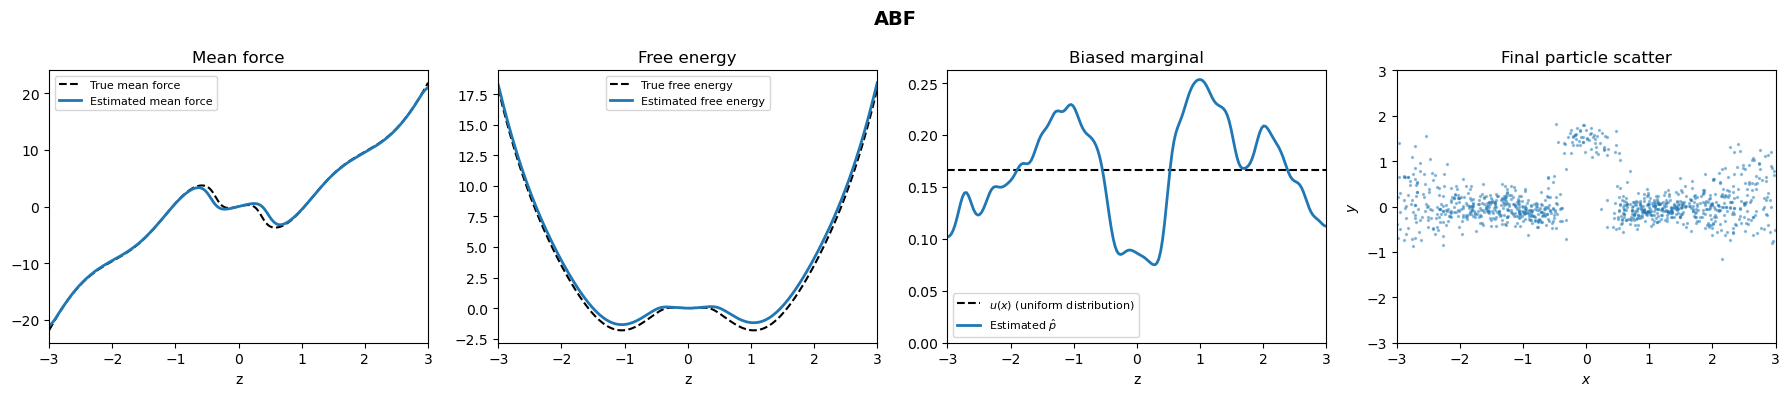

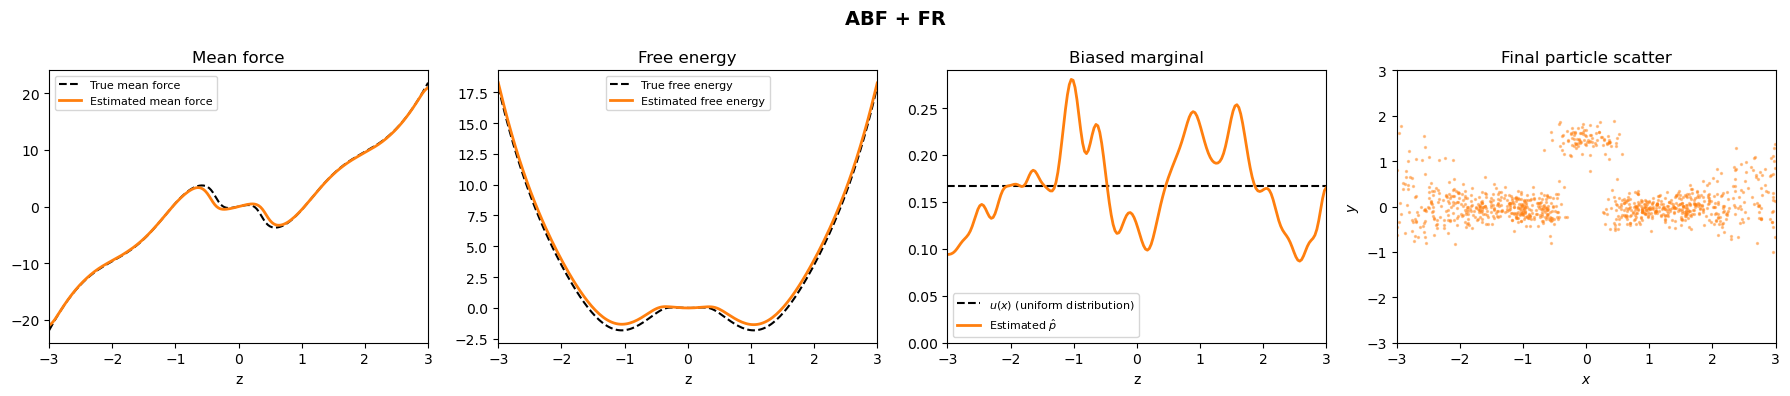

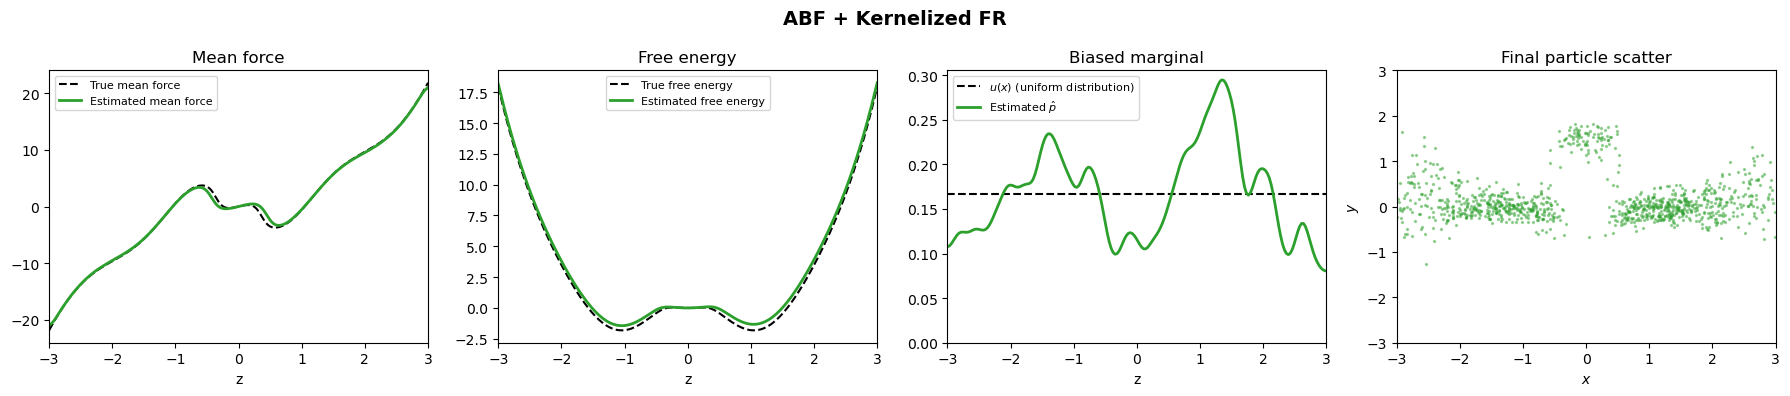

In [12]:
methods = [
    ("ABF",            diag_abf,    "C0"),
    ("ABF + FR",     diag_simple, "C1"),
    ("ABF + Kernelized FR", diag_kernel, "C2"),
]

for label, d, col in methods:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(label, fontsize=14, fontweight='bold')

    # ── 1. Mean force ──────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(z_grid, Fprime_ref, 'k--', lw=1.5, label="True mean force")
    ax.plot(z_grid, d['Ahat_prime'][-1], color=col, lw=2, label="Estimated mean force")

    ax.set_xlabel("z"); ax.set_title("Mean force")
    ax.legend(fontsize=8); ax.set_xlim(ZMIN, ZMAX)

    # ── 2. Free energy ─────────────────────────────────────────────────────
    ax = axes[1]
    ax.plot(z_grid, F_ref, 'k--', lw=1.5, label="True free energy")
    ax.plot(z_grid, d['Ahat'][-1], color=col, lw=2, label="Estimated free energy")
    ax.set_xlabel("z"); ax.set_title("Free energy")
    ax.legend(fontsize=8); ax.set_xlim(ZMIN, ZMAX)

    # ── 3. Biased x-marginal vs flat target u = 1/6 ───────────────────────
    ax = axes[2]
    ax.plot(z_grid, u_target, 'k--', lw=1.5, label=r"$u(x)$ (uniform distribution)")
    ax.plot(z_grid, d['p_hat_grid'][-1], color=col, lw=2, label=r"Estimated $\hat p$")
    ax.set_xlabel("z")
    ax.set_title(r"Biased marginal")
    ax.legend(fontsize=8); ax.set_xlim(ZMIN, ZMAX); ax.set_ylim(bottom=0)

    # ── 4. Particle scatter ────────────────────────────────────────────────
    ax = axes[3]
    Xs, Ys = d['X_snap'][-1], d['Y_snap'][-1]
    ax.scatter(Xs, Ys, s=2, alpha=0.4, color=col, rasterized=True)
    ax.set_xlim(ZMIN, ZMAX); ax.set_ylim(YMIN, YMAX)
    ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$y$")
    ax.set_title("Final particle scatter")

    plt.tight_layout()
    plt.show()

### Method comparison

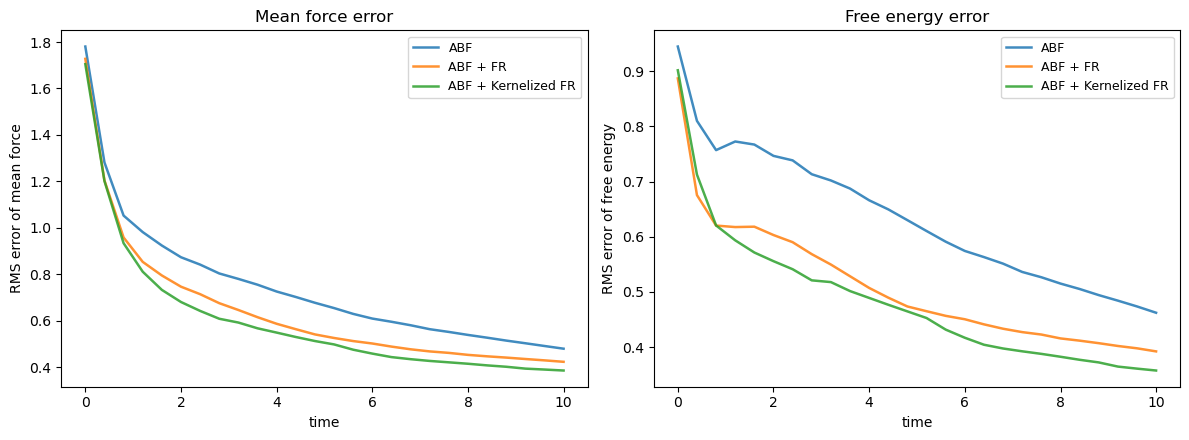

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── 1. Mean-force L2 error ────────────────────────────────────────────────
ax = axes[0]
for lbl, d, col in methods:
    t_arr = np.array(d['steps']) * dt
    ax.plot(t_arr, d['l2_fprime'], color=col, lw=1.8, label=lbl, alpha=0.85)
ax.set_xlabel("time")
ax.set_ylabel(r"RMS error of mean force")
ax.set_title(r"Mean force error")
ax.legend(fontsize=9)
#ax.set_yscale('log')

# ── 2. Free-energy L2 error ───────────────────────────────────────────────
ax = axes[1]
for lbl, d, col in methods:
    t_arr = np.array(d['steps']) * dt
    ax.plot(t_arr, d['l2_f'], color=col, lw=1.8, label=lbl, alpha=0.85)
ax.set_xlabel("time")
ax.set_ylabel(r"RMS error of free energy")
ax.set_title(r"Free energy error")
ax.legend(fontsize=9)
#ax.set_yscale('log')

plt.tight_layout()
plt.show()

## An additional example of metastable dynamics

$$
V(x, y) = \frac{1}{6} \left[ 4 (1 - x^2 - y^2)^2 + 2 (x^2 - 2)^2 + ((x + y)^2 - 1)^2 + ((x - y)^2 - 1)^2 \right]
$$

with reaction coordinate $\xi (x, y) = x$.

### Local setup for the metastable example

In [14]:
ZMIN_meta, ZMAX_meta = -1.8, 1.8
YMIN_meta, YMAX_meta = -1.8, 1.8

beta_meta = 6.0

N_meta          = 600
dt_meta         = 1e-3
n_steps_meta    = 3000
save_every_meta = 200

gamma_meta = 1.

h_meta   = 0.04
eta_meta = 0.02

n_grid_meta = 200
z_grid_meta = np.linspace(ZMIN_meta, ZMAX_meta, n_grid_meta)
dz_meta     = z_grid_meta[1] - z_grid_meta[0]

n_quad_meta = 200
y_quad_meta = np.linspace(YMIN_meta, YMAX_meta, n_quad_meta)

u_target_meta = np.full(n_grid_meta, 1.0 / (ZMAX_meta - ZMIN_meta))
EPS_meta = EPS


def reflect_x_meta(q_meta):
    """Reflect x-coordinates into [ZMIN_meta, ZMAX_meta]."""
    return _reflect_1d(q_meta, ZMIN_meta, ZMAX_meta)


def reflect_y_meta(q_meta):
    """Reflect y-coordinates into [YMIN_meta, YMAX_meta]."""
    return _reflect_1d(q_meta, YMIN_meta, YMAX_meta)


def V_meta(x_meta, y_meta):
    a_meta = 1.0 - x_meta**2 - y_meta**2
    b_meta = x_meta**2 - 2.0
    c_meta = (x_meta + y_meta)**2 - 1.0
    d_meta = (x_meta - y_meta)**2 - 1.0
    return (4.0 * a_meta**2 + 2.0 * b_meta**2 + c_meta**2 + d_meta**2) / 6.0


def dVdx_meta(x_meta, y_meta):
    a_meta = 1.0 - x_meta**2 - y_meta**2
    b_meta = x_meta**2 - 2.0
    c_meta = (x_meta + y_meta)**2 - 1.0
    d_meta = (x_meta - y_meta)**2 - 1.0
    return (
        -16.0 * x_meta * a_meta
        + 8.0 * x_meta * b_meta
        + 4.0 * c_meta * (x_meta + y_meta)
        + 4.0 * d_meta * (x_meta - y_meta)
    ) / 6.0


def dVdy_meta(x_meta, y_meta):
    a_meta = 1.0 - x_meta**2 - y_meta**2
    c_meta = (x_meta + y_meta)**2 - 1.0
    d_meta = (x_meta - y_meta)**2 - 1.0
    return (
        -16.0 * y_meta * a_meta
        + 4.0 * c_meta * (x_meta + y_meta)
        - 4.0 * d_meta * (x_meta - y_meta)
    ) / 6.0

### Visualization of metastable potential and target distribution

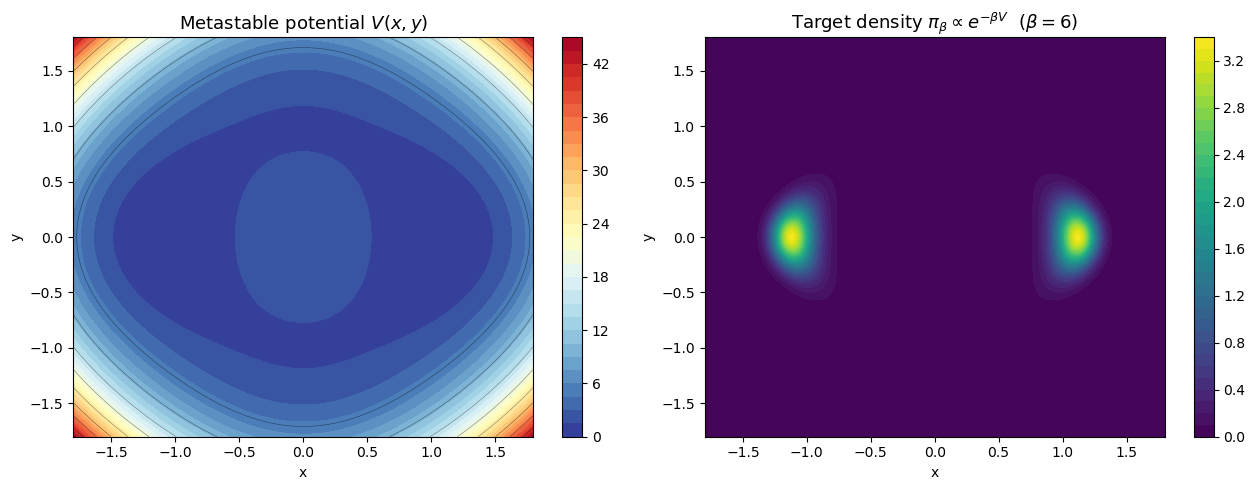

In [15]:
xg_meta = np.linspace(ZMIN_meta, ZMAX_meta, 300)
yg_meta = np.linspace(YMIN_meta, YMAX_meta, 300)
XX_meta, YY_meta = np.meshgrid(xg_meta, yg_meta)

VV_meta = V_meta(XX_meta, YY_meta)
pi_beta_raw_meta = np.exp(-beta_meta * (VV_meta - np.min(VV_meta)))
norm_pi_meta = np.trapezoid(
    np.trapezoid(pi_beta_raw_meta, xg_meta, axis=1), yg_meta
)
pi_beta_meta = pi_beta_raw_meta / norm_pi_meta

fig_meta, axes_meta = plt.subplots(1, 2, figsize=(13, 5))

c0_meta = axes_meta[0].contourf(XX_meta, YY_meta, VV_meta, levels=40, cmap='RdYlBu_r')
axes_meta[0].contour(XX_meta, YY_meta, VV_meta, levels=10, colors='k', linewidths=0.4, alpha=0.5)
plt.colorbar(c0_meta, ax=axes_meta[0])
axes_meta[0].set_title(r"Metastable potential $V(x,y)$", fontsize=13)
axes_meta[0].set_xlabel("x"); axes_meta[0].set_ylabel("y")

c1_meta = axes_meta[1].contourf(XX_meta, YY_meta, pi_beta_meta, levels=40, cmap='viridis')
plt.colorbar(c1_meta, ax=axes_meta[1])
axes_meta[1].set_title(r"Target density $\pi_\beta \propto e^{-\beta V}$  ($\beta=%g$)" % beta_meta,
                  fontsize=13)
axes_meta[1].set_xlabel("x"); axes_meta[1].set_ylabel("y")

plt.tight_layout()
plt.show()

### Reference free energy and mean force for the metastable example

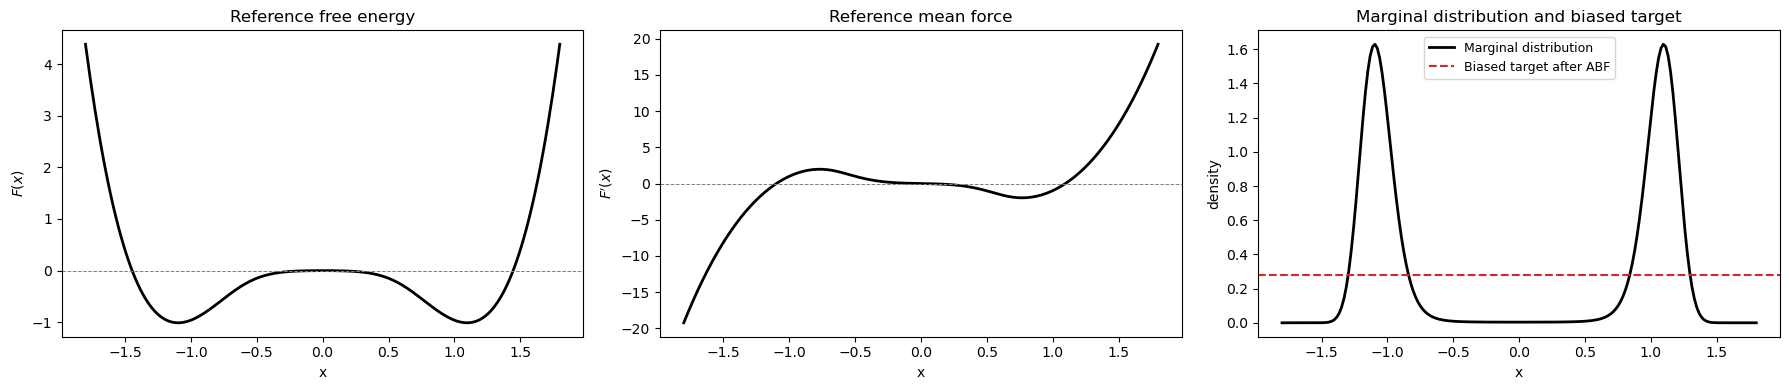

In [16]:
def compute_reference_meta(z_grid_meta, y_quad_meta, beta_meta):
    """Compute the x-marginal reference free energy and mean force."""
    n_z_meta = len(z_grid_meta)
    n_y_meta = len(y_quad_meta)

    zz_meta = z_grid_meta[:, None] * np.ones((1, n_y_meta))
    yy_meta = np.ones((n_z_meta, 1)) * y_quad_meta[None, :]

    phi_meta = beta_meta * V_meta(zz_meta, yy_meta)
    dvdx_mat_meta = dVdx_meta(zz_meta, yy_meta)

    m_meta = phi_meta.min(axis=1, keepdims=True)
    w_meta = np.exp(-(phi_meta - m_meta))

    Z_stab_meta = np.trapezoid(w_meta, y_quad_meta, axis=1)
    log_Z_meta = -m_meta[:, 0] + np.log(np.maximum(Z_stab_meta, EPS_meta))

    Fprime_ref_meta = (
        np.trapezoid(dvdx_mat_meta * w_meta, y_quad_meta, axis=1)
        / np.maximum(Z_stab_meta, EPS_meta)
    )

    idx0_meta = np.argmin(np.abs(z_grid_meta))
    F_ref_meta = -(1.0 / beta_meta) * (log_Z_meta - log_Z_meta[idx0_meta])

    return log_Z_meta, F_ref_meta, Fprime_ref_meta


log_Z_meta, F_ref_meta, Fprime_ref_meta = compute_reference_meta(
    z_grid_meta, y_quad_meta, beta_meta
)

_lz_meta = log_Z_meta - log_Z_meta.max()
_p_unnorm_meta = np.exp(_lz_meta)
p_ref_unbiased_meta = _p_unnorm_meta / np.trapezoid(_p_unnorm_meta, z_grid_meta)

fig_meta, axes_meta = plt.subplots(1, 3, figsize=(18, 4))

axes_meta[0].plot(z_grid_meta, F_ref_meta, 'k-', lw=2)
axes_meta[0].axhline(0, color='gray', lw=0.7, ls='--')
axes_meta[0].set_xlabel("x"); axes_meta[0].set_ylabel(r"$F(x)$")
axes_meta[0].set_title(r"Reference free energy")

axes_meta[1].plot(z_grid_meta, Fprime_ref_meta, 'k-', lw=2)
axes_meta[1].axhline(0, color='gray', lw=0.7, ls='--')
axes_meta[1].set_xlabel("x"); axes_meta[1].set_ylabel(r"$F'(x)$")
axes_meta[1].set_title(r"Reference mean force")

axes_meta[2].plot(z_grid_meta, p_ref_unbiased_meta, 'k-', lw=2, label="Marginal distribution")
axes_meta[2].axhline(1.0 / (ZMAX_meta - ZMIN_meta), color='C3', lw=1.5, ls='--',
                label="Biased target after ABF")
axes_meta[2].set_xlabel("x"); axes_meta[2].set_ylabel("density")
axes_meta[2].set_title("Marginal distribution and biased target")
axes_meta[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Metastable ABF and Fisher-Rao helpers

In [17]:
def K_h_meta(u_meta, h_val_meta=h_meta):
    return gaussian_kernel(u_meta, h_val_meta)


def K_eta_meta(u_meta, eta_val_meta=eta_meta):
    return gaussian_kernel(u_meta, eta_val_meta)


def compute_p_hat_meta(x_eval_meta, X_tilde_meta, eta_val_meta=eta_meta):
    x_eval_meta = np.atleast_1d(np.asarray(x_eval_meta, dtype=float))
    N_part_meta = len(X_tilde_meta)
    X_left_meta = 2.0 * ZMIN_meta - X_tilde_meta
    X_right_meta = 2.0 * ZMAX_meta - X_tilde_meta
    X_all_meta = np.concatenate([X_left_meta, X_tilde_meta, X_right_meta])
    diff_meta = x_eval_meta[:, None] - X_all_meta[None, :]
    p_meta = np.sum(K_eta_meta(diff_meta, eta_val_meta), axis=1) / N_part_meta
    return np.maximum(p_meta, EPS_meta)


def update_abf_accumulators_meta(num_acc_meta, den_acc_meta, X_meta, Y_meta,
                                 z_grid_meta, h_val_meta=h_meta):
    """Add the current metastable particle batch to ABF accumulators."""
    diff_meta = z_grid_meta[:, None] - X_meta[None, :]
    weights_meta = K_h_meta(diff_meta, h_val_meta)
    num_acc_meta += np.sum(weights_meta * dVdx_meta(X_meta, Y_meta)[None, :], axis=1)
    den_acc_meta += np.sum(weights_meta, axis=1)


def score_simple_meta(X_tilde_meta, p_hat_at_particles_meta,
                      p_hat_on_grid_meta, z_grid_meta):
    log_p_meta = np.log(np.maximum(p_hat_at_particles_meta, EPS_meta))
    grid_baseline_meta = np.trapezoid(
        p_hat_on_grid_meta * np.log(np.maximum(p_hat_on_grid_meta, EPS_meta)),
        z_grid_meta,
    )
    return log_p_meta - grid_baseline_meta


def score_kernelized_meta(X_tilde_meta, p_hat_at_particles_meta,
                          p_hat_on_grid_meta, z_grid_meta,
                          eta_val_meta=eta_meta):
    log_p_meta = np.log(np.maximum(p_hat_at_particles_meta, EPS_meta))
    grid_baseline_meta = np.trapezoid(
        p_hat_on_grid_meta * np.log(np.maximum(p_hat_on_grid_meta, EPS_meta)),
        z_grid_meta,
    )
    diff_meta = X_tilde_meta[:, None] - X_tilde_meta[None, :]
    K_mat_meta = K_eta_meta(diff_meta, eta_val_meta)
    kernel_term_meta = np.mean(
        K_mat_meta / np.maximum(p_hat_at_particles_meta[None, :], EPS_meta),
        axis=1,
    )
    return log_p_meta + kernel_term_meta - grid_baseline_meta - 1.0

### Metastable simulation methods

In [18]:
def simulate_abf_only_meta(N_meta, dt_meta, n_steps_meta, save_every_meta,
                           beta_meta, h_meta, eta_meta,
                           z_grid_meta, F_ref_meta, Fprime_ref_meta,
                           rng_meta=None):
    if rng_meta is None:
        rng_meta = np.random.default_rng()

    X_meta = rng_meta.uniform(ZMIN_meta, ZMAX_meta, size=N_meta)
    Y_meta = rng_meta.uniform(YMIN_meta, YMAX_meta, size=N_meta)
    noise_scale_meta = np.sqrt(2.0 * dt_meta / beta_meta)

    num_acc_meta, den_acc_meta = init_abf_accumulators(len(z_grid_meta))

    diag_meta = dict(steps=[], Ahat_prime=[], Ahat=[], p_hat_grid=[],
                     l2_fprime=[], l2_f=[], X_snap=[], Y_snap=[])

    for step_meta in range(n_steps_meta):
        update_abf_accumulators_meta(
            num_acc_meta, den_acc_meta, X_meta, Y_meta, z_grid_meta, h_meta
        )
        Ahat_prime_meta = compute_abf_prime_from_acc(num_acc_meta, den_acc_meta)
        Ahat_meta = integrate_abf_prime(Ahat_prime_meta, z_grid_meta)
        abf_at_X_meta = make_abf_interpolant(Ahat_prime_meta, z_grid_meta)(X_meta)

        X_tilde_meta = (
            X_meta
            + (-dVdx_meta(X_meta, Y_meta) + abf_at_X_meta) * dt_meta
            + noise_scale_meta * rng_meta.standard_normal(N_meta)
        )
        Y_tilde_meta = (
            Y_meta
            + (-dVdy_meta(X_meta, Y_meta)) * dt_meta
            + noise_scale_meta * rng_meta.standard_normal(N_meta)
        )

        X_meta = reflect_x_meta(X_tilde_meta)
        Y_meta = reflect_y_meta(Y_tilde_meta)

        if step_meta % save_every_meta == 0 or step_meta == n_steps_meta - 1:
            p_hat_g_meta = compute_p_hat_meta(z_grid_meta, X_meta, eta_meta)
            idx0_meta = np.argmin(np.abs(z_grid_meta))
            Ahat_sh_meta = Ahat_meta - Ahat_meta[idx0_meta]
            diag_meta['steps'].append(step_meta)
            diag_meta['Ahat_prime'].append(Ahat_prime_meta.copy())
            diag_meta['Ahat'].append(Ahat_sh_meta.copy())
            diag_meta['p_hat_grid'].append(p_hat_g_meta.copy())
            diag_meta['l2_fprime'].append(np.sqrt(np.mean((Ahat_prime_meta - Fprime_ref_meta)**2)))
            diag_meta['l2_f'].append(np.sqrt(np.mean((Ahat_sh_meta - F_ref_meta)**2)))
            diag_meta['X_snap'].append(X_meta.copy())
            diag_meta['Y_snap'].append(Y_meta.copy())

    return diag_meta


def simulate_abf_fr_simple_meta(N_meta, dt_meta, n_steps_meta, save_every_meta,
                                beta_meta, h_meta, eta_meta, gamma_meta,
                                z_grid_meta, F_ref_meta, Fprime_ref_meta,
                                rng_meta=None):
    if rng_meta is None:
        rng_meta = np.random.default_rng()

    X_meta = rng_meta.uniform(ZMIN_meta, ZMAX_meta, size=N_meta)
    Y_meta = rng_meta.uniform(YMIN_meta, YMAX_meta, size=N_meta)
    noise_scale_meta = np.sqrt(2.0 * dt_meta / beta_meta)

    num_acc_meta, den_acc_meta = init_abf_accumulators(len(z_grid_meta))

    diag_meta = dict(steps=[], Ahat_prime=[], Ahat=[], p_hat_grid=[],
                     l2_fprime=[], l2_f=[], X_snap=[], Y_snap=[])

    for step_meta in range(n_steps_meta):
        update_abf_accumulators_meta(
            num_acc_meta, den_acc_meta, X_meta, Y_meta, z_grid_meta, h_meta
        )
        Ahat_prime_meta = compute_abf_prime_from_acc(num_acc_meta, den_acc_meta)
        Ahat_meta = integrate_abf_prime(Ahat_prime_meta, z_grid_meta)
        abf_at_X_meta = make_abf_interpolant(Ahat_prime_meta, z_grid_meta)(X_meta)

        X_tilde_meta = (
            X_meta
            + (-dVdx_meta(X_meta, Y_meta) + abf_at_X_meta) * dt_meta
            + noise_scale_meta * rng_meta.standard_normal(N_meta)
        )
        Y_tilde_meta = (
            Y_meta
            + (-dVdy_meta(X_meta, Y_meta)) * dt_meta
            + noise_scale_meta * rng_meta.standard_normal(N_meta)
        )

        X_tilde_meta = reflect_x_meta(X_tilde_meta)
        Y_tilde_meta = reflect_y_meta(Y_tilde_meta)

        p_hat_vals_meta = compute_p_hat_meta(X_tilde_meta, X_tilde_meta, eta_meta)
        p_hat_on_grid_meta = compute_p_hat_meta(z_grid_meta, X_tilde_meta, eta_meta)
        S_meta = score_simple_meta(
            X_tilde_meta, p_hat_vals_meta, p_hat_on_grid_meta, z_grid_meta
        )
        X_meta, Y_meta = resample_fixed_N(
            X_tilde_meta, Y_tilde_meta, S_meta, gamma_meta, dt_meta, rng_meta
        )

        if step_meta % save_every_meta == 0 or step_meta == n_steps_meta - 1:
            p_hat_g_meta = compute_p_hat_meta(z_grid_meta, X_meta, eta_meta)
            idx0_meta = np.argmin(np.abs(z_grid_meta))
            Ahat_sh_meta = Ahat_meta - Ahat_meta[idx0_meta]
            diag_meta['steps'].append(step_meta)
            diag_meta['Ahat_prime'].append(Ahat_prime_meta.copy())
            diag_meta['Ahat'].append(Ahat_sh_meta.copy())
            diag_meta['p_hat_grid'].append(p_hat_g_meta.copy())
            diag_meta['l2_fprime'].append(np.sqrt(np.mean((Ahat_prime_meta - Fprime_ref_meta)**2)))
            diag_meta['l2_f'].append(np.sqrt(np.mean((Ahat_sh_meta - F_ref_meta)**2)))
            diag_meta['X_snap'].append(X_meta.copy())
            diag_meta['Y_snap'].append(Y_meta.copy())

    return diag_meta


def simulate_abf_fr_kernelized_meta(N_meta, dt_meta, n_steps_meta, save_every_meta,
                                    beta_meta, h_meta, eta_meta, gamma_meta,
                                    z_grid_meta, F_ref_meta, Fprime_ref_meta,
                                    rng_meta=None):
    if rng_meta is None:
        rng_meta = np.random.default_rng()

    X_meta = rng_meta.uniform(ZMIN_meta, ZMAX_meta, size=N_meta)
    Y_meta = rng_meta.uniform(YMIN_meta, YMAX_meta, size=N_meta)
    noise_scale_meta = np.sqrt(2.0 * dt_meta / beta_meta)

    num_acc_meta, den_acc_meta = init_abf_accumulators(len(z_grid_meta))

    diag_meta = dict(steps=[], Ahat_prime=[], Ahat=[], p_hat_grid=[],
                     l2_fprime=[], l2_f=[], X_snap=[], Y_snap=[])

    for step_meta in range(n_steps_meta):
        update_abf_accumulators_meta(
            num_acc_meta, den_acc_meta, X_meta, Y_meta, z_grid_meta, h_meta
        )
        Ahat_prime_meta = compute_abf_prime_from_acc(num_acc_meta, den_acc_meta)
        Ahat_meta = integrate_abf_prime(Ahat_prime_meta, z_grid_meta)
        abf_at_X_meta = make_abf_interpolant(Ahat_prime_meta, z_grid_meta)(X_meta)

        X_tilde_meta = (
            X_meta
            + (-dVdx_meta(X_meta, Y_meta) + abf_at_X_meta) * dt_meta
            + noise_scale_meta * rng_meta.standard_normal(N_meta)
        )
        Y_tilde_meta = (
            Y_meta
            + (-dVdy_meta(X_meta, Y_meta)) * dt_meta
            + noise_scale_meta * rng_meta.standard_normal(N_meta)
        )

        X_tilde_meta = reflect_x_meta(X_tilde_meta)
        Y_tilde_meta = reflect_y_meta(Y_tilde_meta)

        p_hat_vals_meta = compute_p_hat_meta(X_tilde_meta, X_tilde_meta, eta_meta)
        p_hat_on_grid_meta = compute_p_hat_meta(z_grid_meta, X_tilde_meta, eta_meta)
        S_meta = score_kernelized_meta(
            X_tilde_meta, p_hat_vals_meta, p_hat_on_grid_meta, z_grid_meta, eta_meta
        )
        X_meta, Y_meta = resample_fixed_N(
            X_tilde_meta, Y_tilde_meta, S_meta, gamma_meta, dt_meta, rng_meta
        )

        if step_meta % save_every_meta == 0 or step_meta == n_steps_meta - 1:
            p_hat_g_meta = compute_p_hat_meta(z_grid_meta, X_meta, eta_meta)
            idx0_meta = np.argmin(np.abs(z_grid_meta))
            Ahat_sh_meta = Ahat_meta - Ahat_meta[idx0_meta]
            diag_meta['steps'].append(step_meta)
            diag_meta['Ahat_prime'].append(Ahat_prime_meta.copy())
            diag_meta['Ahat'].append(Ahat_sh_meta.copy())
            diag_meta['p_hat_grid'].append(p_hat_g_meta.copy())
            diag_meta['l2_fprime'].append(np.sqrt(np.mean((Ahat_prime_meta - Fprime_ref_meta)**2)))
            diag_meta['l2_f'].append(np.sqrt(np.mean((Ahat_sh_meta - F_ref_meta)**2)))
            diag_meta['X_snap'].append(X_meta.copy())
            diag_meta['Y_snap'].append(Y_meta.copy())

    return diag_meta

### Run metastable simulations

In [19]:
import time as time_meta

common_kw_meta = dict(
    N_meta=N_meta, dt_meta=dt_meta, n_steps_meta=n_steps_meta,
    save_every_meta=save_every_meta, beta_meta=beta_meta,
    h_meta=h_meta, eta_meta=eta_meta,
    z_grid_meta=z_grid_meta, F_ref_meta=F_ref_meta,
    Fprime_ref_meta=Fprime_ref_meta,
)

rng_meta = np.random.default_rng(31415)
seeds_meta = rng_meta.integers(0, 2**31, size=3)

print("Running metastable ABF only ...", end=" ", flush=True)
t0_meta = time_meta.time()
diag_abf_meta = simulate_abf_only_meta(
    **common_kw_meta, rng_meta=np.random.default_rng(int(seeds_meta[0]))
)
print(f"done in {time_meta.time()-t0_meta:.1f}s")

print("Running metastable ABF + simple Fisher-Rao ...", end=" ", flush=True)
t0_meta = time_meta.time()
diag_simple_meta = simulate_abf_fr_simple_meta(
    **common_kw_meta, gamma_meta=gamma_meta,
    rng_meta=np.random.default_rng(int(seeds_meta[1])),
)
print(f"done in {time_meta.time()-t0_meta:.1f}s")

print("Running metastable ABF + kernelized Fisher-Rao ...", end=" ", flush=True)
t0_meta = time_meta.time()
diag_kernel_meta = simulate_abf_fr_kernelized_meta(
    **common_kw_meta, gamma_meta=gamma_meta,
    rng_meta=np.random.default_rng(int(seeds_meta[2])),
)
print(f"done in {time_meta.time()-t0_meta:.1f}s")

print("\nFinal metastable L2 errors (mean force and free energy):")
for lbl_meta, d_meta in [
    ("ABF only", diag_abf_meta),
    ("ABF+FR simple", diag_simple_meta),
    ("ABF+FR kernel", diag_kernel_meta),
]:
    print(
        f"  {lbl_meta:20s}: Fprime={d_meta['l2_fprime'][-1]:.4f}   "
        f"F={d_meta['l2_f'][-1]:.4f}"
    )

Running metastable ABF only ... done in 3.9s
Running metastable ABF + simple Fisher-Rao ... done in 44.4s
Running metastable ABF + kernelized Fisher-Rao ... done in 54.0s

Final metastable L2 errors (mean force and free energy):
  ABF only            : Fprime=0.5059   F=0.4256
  ABF+FR simple       : Fprime=0.4304   F=0.3487
  ABF+FR kernel       : Fprime=0.4319   F=0.3535


### Metastable diagnostics

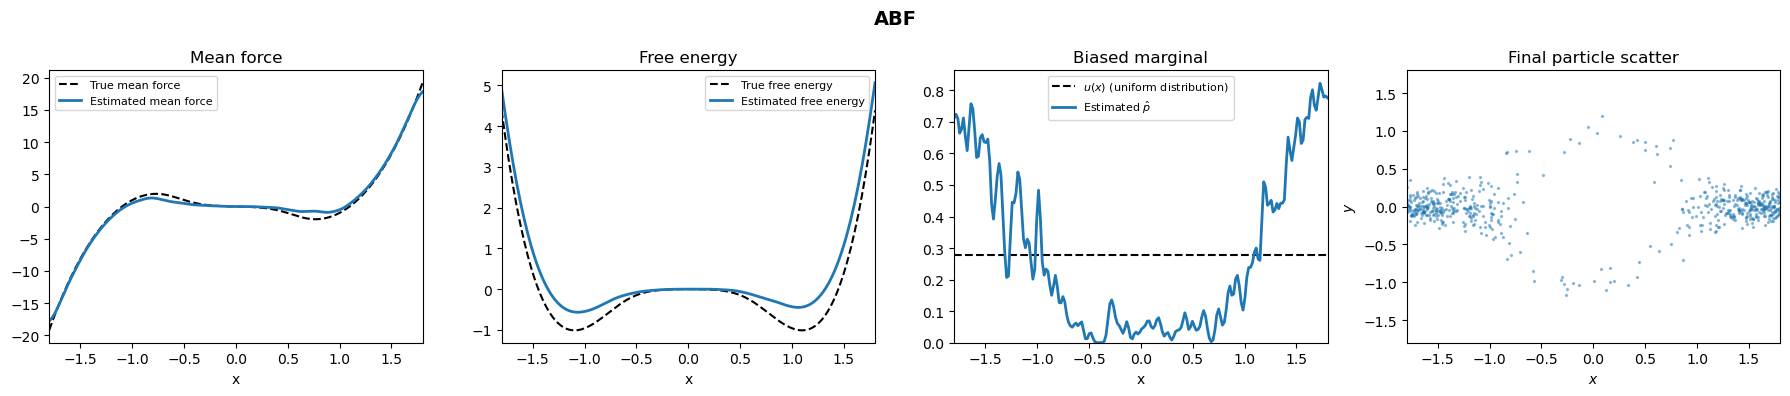

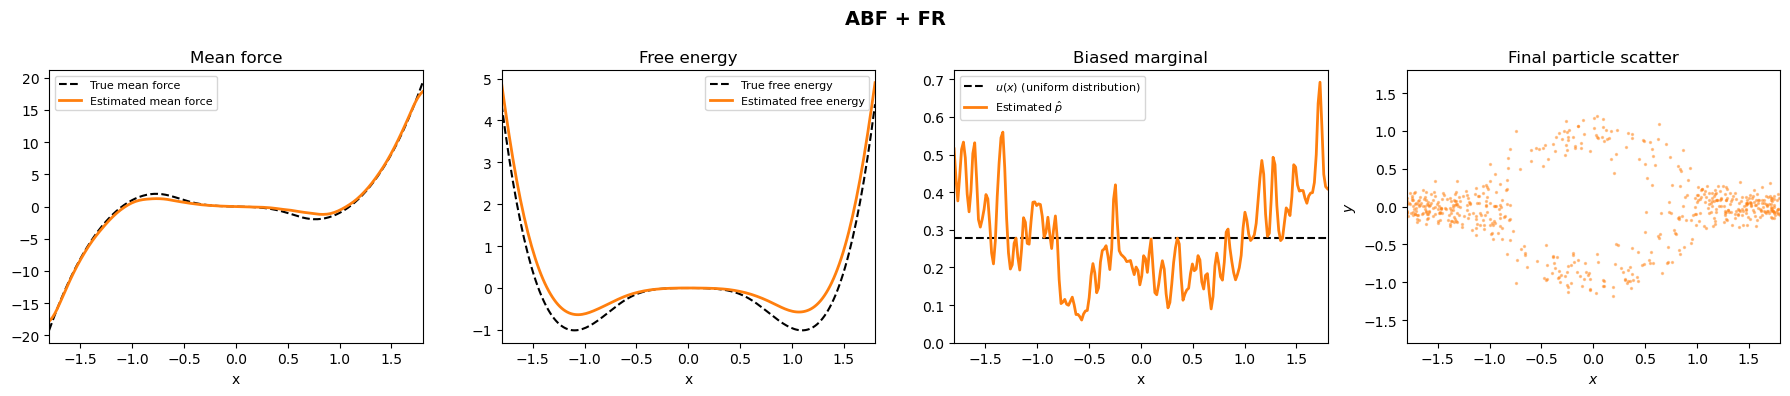

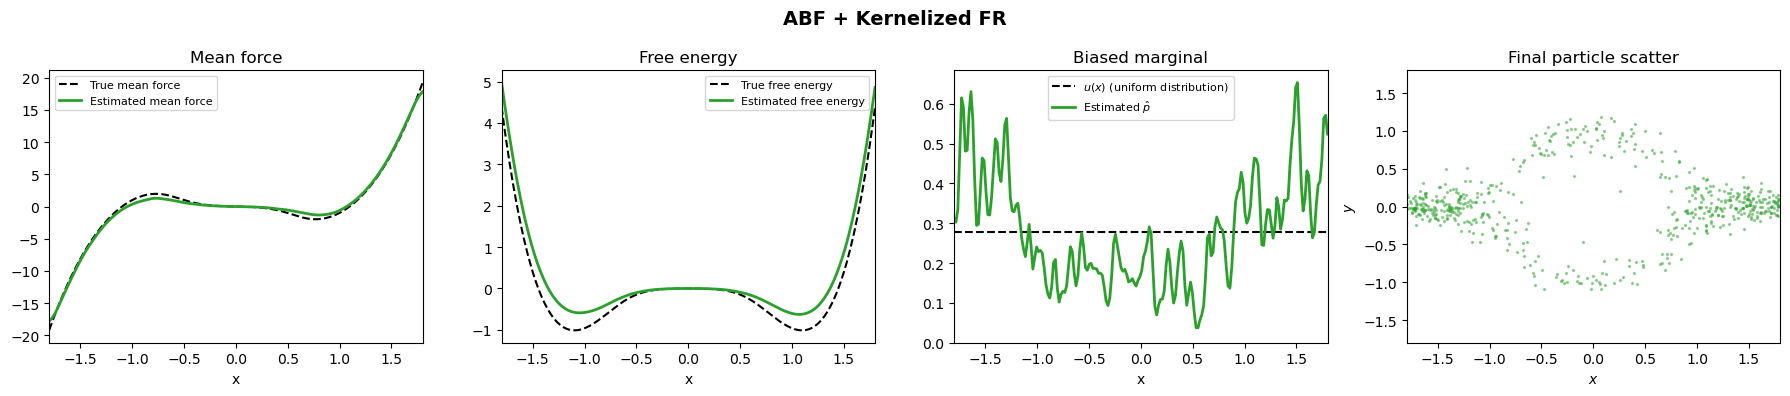

In [20]:
methods_meta = [
    ("ABF", diag_abf_meta, "C0"),
    ("ABF + FR", diag_simple_meta, "C1"),
    ("ABF + Kernelized FR", diag_kernel_meta, "C2"),
]

for label_meta, d_meta, col_meta in methods_meta:
    fig_meta, axes_meta = plt.subplots(1, 4, figsize=(18, 4))
    fig_meta.suptitle(label_meta, fontsize=14, fontweight='bold')

    ax_meta = axes_meta[0]
    ax_meta.plot(z_grid_meta, Fprime_ref_meta, 'k--', lw=1.5, label="True mean force")
    ax_meta.plot(z_grid_meta, d_meta['Ahat_prime'][-1], color=col_meta, lw=2,
                 label="Estimated mean force")
    ax_meta.set_xlabel("x"); ax_meta.set_title("Mean force")
    ax_meta.legend(fontsize=8); ax_meta.set_xlim(ZMIN_meta, ZMAX_meta)

    ax_meta = axes_meta[1]
    ax_meta.plot(z_grid_meta, F_ref_meta, 'k--', lw=1.5, label="True free energy")
    ax_meta.plot(z_grid_meta, d_meta['Ahat'][-1], color=col_meta, lw=2,
                 label="Estimated free energy")
    ax_meta.set_xlabel("x"); ax_meta.set_title("Free energy")
    ax_meta.legend(fontsize=8); ax_meta.set_xlim(ZMIN_meta, ZMAX_meta)

    ax_meta = axes_meta[2]
    ax_meta.plot(z_grid_meta, u_target_meta, 'k--', lw=1.5,
                 label=r"$u(x)$ (uniform distribution)")
    ax_meta.plot(z_grid_meta, d_meta['p_hat_grid'][-1], color=col_meta, lw=2,
                 label=r"Estimated $\hat p$")
    ax_meta.set_xlabel("x")
    ax_meta.set_title(r"Biased marginal")
    ax_meta.legend(fontsize=8); ax_meta.set_xlim(ZMIN_meta, ZMAX_meta)
    ax_meta.set_ylim(bottom=0)

    ax_meta = axes_meta[3]
    Xs_meta, Ys_meta = d_meta['X_snap'][-1], d_meta['Y_snap'][-1]
    ax_meta.scatter(Xs_meta, Ys_meta, s=2, alpha=0.4, color=col_meta,
                    rasterized=True)
    ax_meta.set_xlim(ZMIN_meta, ZMAX_meta); ax_meta.set_ylim(YMIN_meta, YMAX_meta)
    ax_meta.set_xlabel(r"$x$"); ax_meta.set_ylabel(r"$y$")
    ax_meta.set_title("Final particle scatter")

    plt.tight_layout()
    plt.show()

### Metastable method comparison

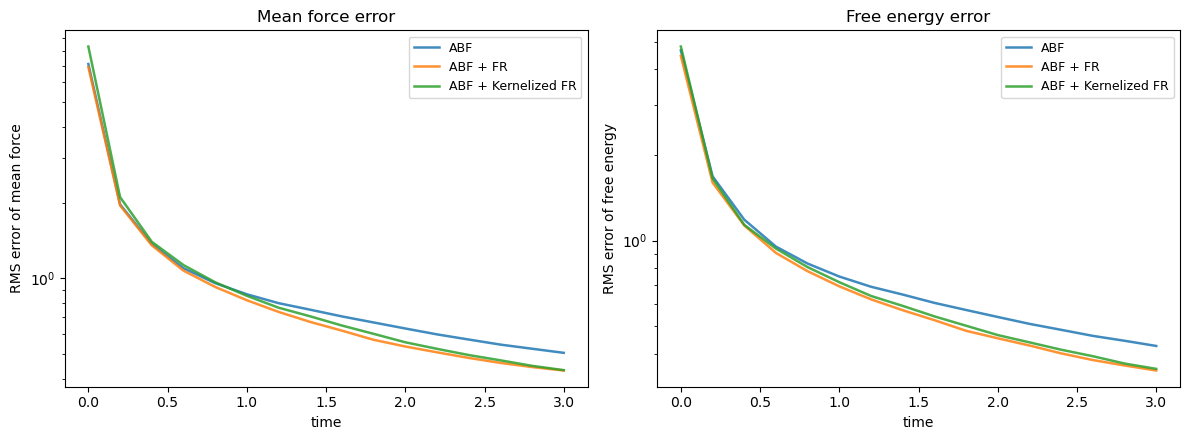

In [21]:
fig_meta, axes_meta = plt.subplots(1, 2, figsize=(12, 4.5))

ax_meta = axes_meta[0]
for lbl_meta, d_meta, col_meta in methods_meta:
    t_arr_meta = np.array(d_meta['steps']) * dt_meta
    ax_meta.plot(t_arr_meta, d_meta['l2_fprime'], color=col_meta, lw=1.8,
                 label=lbl_meta, alpha=0.85)
ax_meta.set_xlabel("time")
ax_meta.set_ylabel(r"RMS error of mean force")
ax_meta.set_title(r"Mean force error")
ax_meta.legend(fontsize=9)
ax_meta.set_yscale('log')

ax_meta = axes_meta[1]
for lbl_meta, d_meta, col_meta in methods_meta:
    t_arr_meta = np.array(d_meta['steps']) * dt_meta
    ax_meta.plot(t_arr_meta, d_meta['l2_f'], color=col_meta, lw=1.8,
                 label=lbl_meta, alpha=0.85)
ax_meta.set_xlabel("time")
ax_meta.set_ylabel(r"RMS error of free energy")
ax_meta.set_title(r"Free energy error")
ax_meta.legend(fontsize=9)
ax_meta.set_yscale('log')

plt.tight_layout()
plt.show()